<a href="https://colab.research.google.com/github/fboldt/aulasml/blob/master/aula02c%20-%20classificador%20de%20vizinhan%C3%A7a.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [60]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split

X, y = load_wine(return_X_y=True)
X_reduced = X[:, [6,9]]
X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, test_size=0.2, random_state=42)

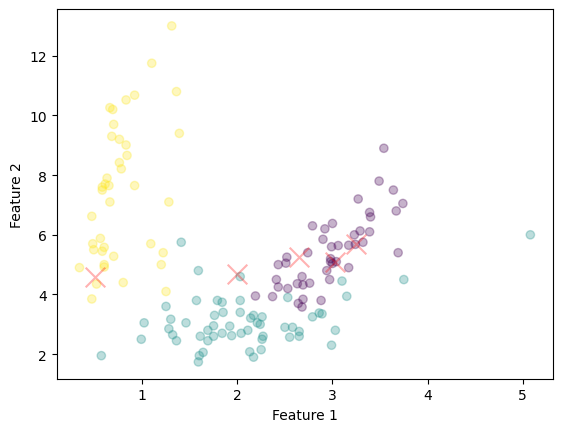

In [61]:
from matplotlib import pyplot as plt

plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="viridis", alpha=0.3)
plt.scatter(X_test[:5, 0], X_test[:5, 1], c='r', marker='x', s=200, alpha=0.3)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [62]:
set(y_train)

{np.int64(0), np.int64(1), np.int64(2)}

In [63]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score
import numpy as np

class K1NN(BaseEstimator, ClassifierMixin):
  def fit(self, X, y):
    self.X = X
    self.y = y
    return self

  def pitagoras(self, X):
    return np.sum((self.X - X)**2, axis=1)**0.5

  def predict(self, X):
    y_pred = np.zeros(X.shape[0])
    for i in range(X.shape[0]):
      distances = self.pitagoras(X[i])
      min_index = np.argmin(distances)
      y_pred[i] = self.y[min_index]
    return y_pred

model = K1NN()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(f"accuracy: {accuracy_score(y_test, y_pred)}")

accuracy: 0.9444444444444444


In [64]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = K1NN()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(f"accuracy: {accuracy_score(y_test, y_pred)}")

accuracy: 0.7777777777777778


In [66]:
import pandas as pd

wine = load_wine()

df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


In [68]:
print(f"Max: {X.max(axis=0)}")
print(f"Min: {X.min(axis=0)}")

Max: [1.483e+01 5.800e+00 3.230e+00 3.000e+01 1.620e+02 3.880e+00 5.080e+00
 6.600e-01 3.580e+00 1.300e+01 1.710e+00 4.000e+00 1.680e+03]
Min: [1.103e+01 7.400e-01 1.360e+00 1.060e+01 7.000e+01 9.800e-01 3.400e-01
 1.300e-01 4.100e-01 1.280e+00 4.800e-01 1.270e+00 2.780e+02]


#MaxMin Normalization

In [69]:
x_train_max = X_train.max(axis=0)
x_train_min = X_train.min(axis=0)

X_train_norm = (X_train - x_train_min) / (x_train_max - x_train_min)
X_test_norm = (X_test - x_train_min) / (x_train_max - x_train_min)

print(f"Max tr: {X_train_norm.max(axis=0)}")
print(f"Min tr: {X_train_norm.min(axis=0)}")
print(f"Max te: {X_test_norm.max(axis=0)}")
print(f"Min te: {X_test_norm.min(axis=0)}")

Max tr: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Min tr: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Max te: [0.86052632 0.75560081 0.80213904 0.74226804 0.57608696 0.8
 0.75738397 0.94339623 0.65506329 0.72468908 0.67479675 0.93406593
 1.10480693]
Min te: [ 0.1        -0.0305499   0.18181818  0.22680412  0.08695652  0.12758621
  0.03375527  0.0754717  -0.00316456 -0.04085258  0.07317073  0.01098901
  0.03703704]


In [70]:
model = K1NN()
model.fit(X_train_norm, y_train)
y_pred = model.predict(X_test_norm)
print(f"accuracy: {accuracy_score(y_test, y_pred)}")

accuracy: 0.9444444444444444


In [71]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_norm = scaler.transform(X_train)
X_test_norm = scaler.transform(X_test)

model = K1NN()
model.fit(X_train_norm, y_train)
y_pred = model.predict(X_test_norm)
print(f"accuracy: {accuracy_score(y_test, y_pred)}")

accuracy: 0.9444444444444444


# Standardization

In [72]:
x_train_mean = X_train.mean(axis=0)
x_train_std = X_train.std(axis=0)

X_train_norm = (X_train - x_train_mean) / x_train_std
X_test_norm = (X_test - x_train_mean) / x_train_std

print(f"Mean tr: {X_train_norm.mean(axis=0)}")
print(f"Std tr: {X_train_norm.std(axis=0)}")
print(f"Mean te: {X_test_norm.mean(axis=0)}")
print(f"Std te: {X_test_norm.std(axis=0)}")

Mean tr: [ 8.30321727e-15 -5.73387191e-16  4.72196617e-15  1.22359087e-16
 -3.69813726e-16  1.83343169e-16  9.90795865e-16 -1.01268759e-15
  3.63558948e-16  3.19775505e-16  1.24626444e-15  1.76697467e-16
 -1.56369440e-18]
Std tr: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Mean te: [ 0.13028396 -0.16124142  0.10079272  0.03117293 -0.23778426  0.04690163
  0.13419196 -0.23884446 -0.14562457  0.00103084  0.02266159  0.12964851
  0.19693424]
Std te: [0.94549584 0.87015188 0.90975138 0.82554542 0.84626227 0.90709006
 0.96978666 0.81939439 0.8946222  0.97650956 0.8806474  0.91019964
 1.18192044]


In [73]:
model = K1NN()
model.fit(X_train_norm, y_train)
y_pred = model.predict(X_test_norm)
print(f"accuracy: {accuracy_score(y_test, y_pred)}")

accuracy: 0.9444444444444444


In [74]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)
X_train_norm = scaler.transform(X_train)
X_test_norm = scaler.transform(X_test)

model = K1NN()
model.fit(X_train_norm, y_train)
y_pred = model.predict(X_test_norm)
print(f"accuracy: {accuracy_score(y_test, y_pred)}")

accuracy: 0.9444444444444444


In [77]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=15)
model.fit(X_train_norm, y_train)
y_pred = model.predict(X_test_norm)
print(f"accuracy: {accuracy_score(y_test, y_pred)}")

accuracy: 0.9722222222222222
